In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
import librosa.display
import soundfile as sf

In [13]:
ipd.Audio("audios/common_voice_uz_27109329.mp3")

In [14]:
data, sr = librosa.load("audios/common_voice_uz_27109329.mp3")

In [57]:
sr

22050

In [15]:
data

array([ 2.6536201e-13,  1.0414682e-12, -5.7028129e-13, ...,
        1.7438180e-05, -9.8316450e-05,  0.0000000e+00],
      shape=(153204,), dtype=float32)

In [16]:
len(data)

153204

<Figure size 1200x300 with 0 Axes>

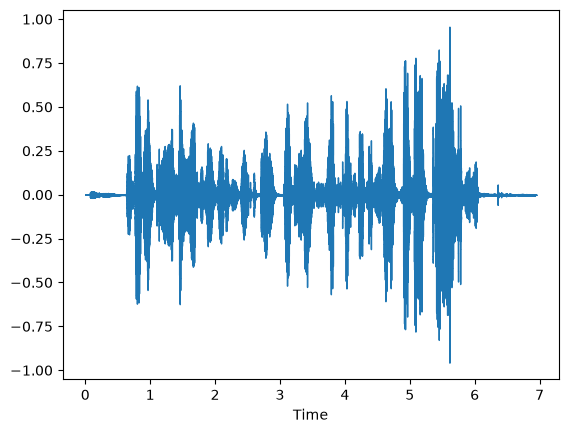

In [40]:
plt.figure(figsize=(12, 3))
plt.figure()
librosa.display.waveshow(data, sr=sr)

In [20]:
def add_white_noise(signal, noise_percentage_factor):
    noise = np.random.normal(0, signal.std(), signal.size)
    augmented_signal = signal + noise_percentage_factor * noise
    # augmented_signal = augmented_signal.astype(type(signal[0]))
    return augmented_signal

In [42]:
augmented_signal = add_white_noise(data, 0.4)

In [43]:
sf.write("audios/augmented_audio_white_noise.wav", augmented_signal, sr)

In [44]:
ipd.Audio("audios/augmented_audio_white_noise.wav")

<Figure size 1200x300 with 0 Axes>

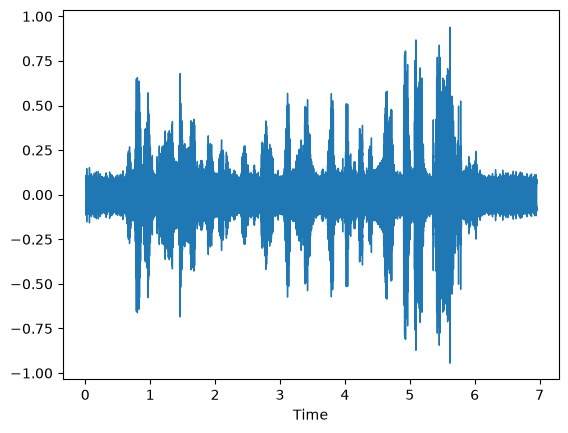

In [45]:
plt.figure(figsize=(12, 3))
plt.figure()
librosa.display.waveshow(augmented_signal, sr=sr)

In [50]:
def time_stretch(signal, time_stretch_factor):
    return librosa.effects.time_stretch(signal, rate=time_stretch_factor)

In [54]:
augmented_signal = time_stretch(data, 1.5)

/media/muzaffar/Data/projects/nlp_audio/.venv/lib/python3.12/site-packages/librosa/effects.py:448: FutureWarning: The `hop_length` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
/media/muzaffar/Data/projects/nlp_audio/.venv/lib/python3.12/site-packages/librosa/effects.py:448: FutureWarning: The `n_fft` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(


In [55]:
sf.write("audios/augmented_audio_time_stretch.wav", augmented_signal, sr)

In [56]:
ipd.Audio("audios/augmented_audio_time_stretch.wav")

In [61]:
def pitch_scale(signal, sr = 22050, num_semitones = 2):
    return librosa.effects.pitch_shift(y = signal, sr = sr, n_steps = num_semitones)

In [73]:
augmented_signal = pitch_scale(data, sr, -2)
sf.write("audios/augmented_audio_pitch_scale.wav", augmented_signal, sr)

In [74]:
ipd.Audio("audios/augmented_audio_pitch_scale.wav")

<Figure size 1200x300 with 0 Axes>

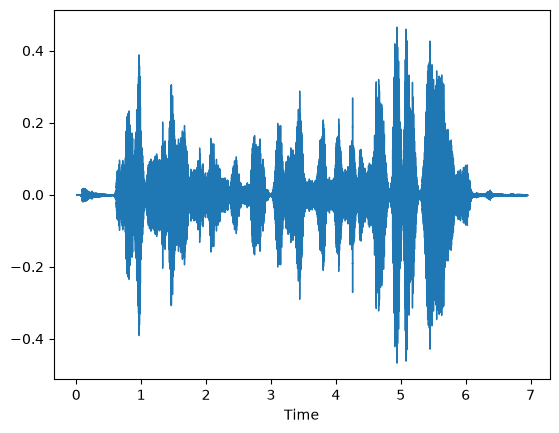

In [75]:
plt.figure(figsize=(12, 3))
plt.figure()
librosa.display.waveshow(augmented_signal, sr=sr)